<a href="https://colab.research.google.com/github/DalleAntoine-99/soil-moisture-monitor/blob/main/bgdia_tp_wgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wasserstein GAN for generation of MNIST digits

This practical session is based on the [DCGAN Pytorch tutorial](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html).

It was adapted by
* Lucía Bouza
* Bruno Galerne
* Arthur Leclaire

You should complete the code regions marked with ###...###.

Don't forget to copy this notebook into your Google drive before working on it.

Also, be sure to connect to a GPU environment, for example T4 (on the top right of the Colab window).
You can check if the GPU works with nvidia-smi.

## Import

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torchvision.utils import make_grid
import torch.utils.data as data

import matplotlib.pyplot as plt
import os
import numpy as np
import time


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device is", device)
# !nvidia-smi

# Displaying function
def imshow(img,size=None):
    img = img*0.5 + 0.5     # unnormalize
    if size is not None:
        img = transforms.Resize(size=size, interpolation=transforms.InterpolationMode.NEAREST, antialias=True)(img)
    pil_img = transforms.functional.to_pil_image(img)
    display(pil_img)
    # print("Image size (h x w): ",  pil_img.height, "x", pil_img.width)
    return None

Device is cpu


## Download MNIST dataset

Note that we normalize the images between -1 and 1 because during sampling, we have to limit the input space and scaling between -1 and 1 makes it easier to implement it. We discard the last batch so that all batches have the same size.

In [2]:
batch_size=128
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
train_loader = data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 24.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 630kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.19MB/s]


QUESTION: Draw a batch of real images with the train_loader and display them. Use `next` and `iter` to get a batch from `train_loader`.

torch.Size([128, 1, 28, 28])


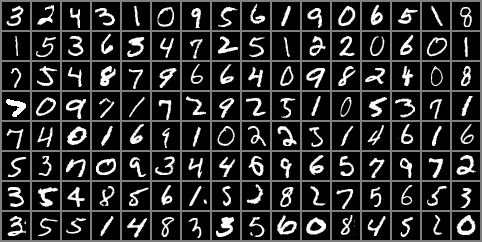

In [3]:
real,_ = next(iter(train_loader))
print(real.shape)

pil_img = imshow(make_grid(real.to('cpu'),nrow=16))

## Generator and Discriminator Models

The architecture of DCGAN is described in the [(Radford et al., 2016)](https://arxiv.org/pdf/1511.06434.pdf)

QUESTION: Examine the architecture of the following generator and discriminator.

In [4]:
# Size  of generator input
nz = 100

# Size of feature maps in generator and discriminator
ngf, ndf = 64, 64

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(in_channels = nz, out_channels = ngf * 8, kernel_size = 4, stride = 1, padding = 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(in_channels = ngf * 8, out_channels = ngf * 4, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(in_channels = ngf * 4, out_channels = ngf * 2, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(in_channels = ngf * 2, out_channels = ngf, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d(in_channels = ngf, out_channels = 1, kernel_size=1, stride=1, padding=2, bias=False),
            nn.Tanh()
            # output size. 1 x 28 x 28
        )

    def forward(self, input):
        return self.main(input)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input is 1 x 28 x 28
            nn.Conv2d(in_channels = 1, out_channels = ndf, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 14 x 14
            nn.Conv2d(in_channels = ndf, out_channels= ndf * 2, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 8 x 8
            nn.Conv2d(in_channels = ndf * 2, out_channels = ndf * 4, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 4 x 4
            nn.Conv2d(in_channels = ndf * 4, out_channels = 1, kernel_size = 4, stride = 2, padding = 1, bias=False)
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

## Weight initialization

The DCGAN [paper](https://arxiv.org/pdf/1511.06434.pdf) mentions that all model weights shall be randomly initialized from a Normal distribution with $\mu=0$ and $\sigma=0.02$. We implement `weights_init` function to reinitialize the weights.

In [7]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Create the generator and discriminator
G = Generator().to(device)
D = Discriminator().to(device)

# Apply the weights_init function to randomly initialize all weights to mean=0, stdev=0.02.
G.apply(weights_init);
D.apply(weights_init);

## Print Architectures of Generator and Discriminator

In [8]:
import torchsummary

# Create some generator and discriminator
G = Generator().to(device)
D = Discriminator().to(device)

torchsummary.summary(G, input_size=(nz,1,1))
torchsummary.summary(D, input_size=(1,28,28))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 512, 4, 4]         819,200
       BatchNorm2d-2            [-1, 512, 4, 4]           1,024
              ReLU-3            [-1, 512, 4, 4]               0
   ConvTranspose2d-4            [-1, 256, 8, 8]       2,097,152
       BatchNorm2d-5            [-1, 256, 8, 8]             512
              ReLU-6            [-1, 256, 8, 8]               0
   ConvTranspose2d-7          [-1, 128, 16, 16]         524,288
       BatchNorm2d-8          [-1, 128, 16, 16]             256
              ReLU-9          [-1, 128, 16, 16]               0
  ConvTranspose2d-10           [-1, 64, 32, 32]         131,072
      BatchNorm2d-11           [-1, 64, 32, 32]             128
             ReLU-12           [-1, 64, 32, 32]               0
  ConvTranspose2d-13            [-1, 1, 28, 28]              64
             Tanh-14            [-1, 1,

## Display Samples of the Generator

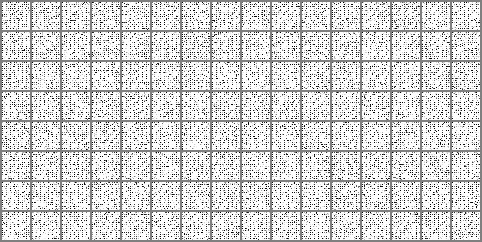

In [9]:
# function to display samples of the generator
def show(G,z=None,batch_size=128,nz=100):
  # provide random latent code as option to see evolution
  with torch.no_grad():
    if z==None:
      z = torch.randn(batch_size,nz,1,1).to(device)
    genimages = G(z)
    pil_img = imshow(utils.make_grid(genimages.to('cpu'),nrow=16))
    return(pil_img)

show(G);

<br/><br/><br/><br/><br/>

# Part 1: DCGAN Training with WGAN-GP loss

<br/><br/>


**QUESTION:** Understand the following function that computes the mean variation and the gradient penalty of D:
$$ \mathsf{MV}(D) = \mathbb{E}\Big[ \| \nabla D(A)\| \Big] $$
$$ \mathsf{GP}(D) = \mathbb{E}\Big[ ( \| \nabla D(A)\| - 1 )^2 \Big] $$
where $A$ is drawn uniformly on a random segment $[X,Y]$.

In [10]:
def meanvariation(D,x,y):
    # Calculate interpolation between points in batches x and y (of same size b)
    b = x.shape[0]
    if y.shape[0]!=b:
        print('wrong size')
    alpha = torch.rand((b,1,1,1),device=device)
    a = alpha * y + (1 - alpha) * x
    a.requires_grad_()

    # Calculate probability of interpolated examples
    Da = D(a).view(-1)

    # Calculate gradients of probabilities with respect to examples
    gradout = torch.ones(Da.size()).to(device)
    gradients = torch.autograd.grad(outputs=Da, inputs=a, grad_outputs=gradout,
       create_graph=True, retain_graph=True)[0]

    # Derivatives of the gradient close to 0 can cause problems because of
    # the square root, so manually calculate norm and add epsilon
    gradients_norm = torch.sqrt(torch.sum(gradients ** 2, dim=[1,2,3]))

    # Return gradient penalty
    return torch.mean(gradients_norm)

def gradient_penalty(D,x,y):
    # Calculate interpolation
    b = x.shape[0]
    if y.shape[0]!=b:
        print('wrong size')
    alpha = torch.rand((b,1,1,1),device=device)
    interp = (alpha * y + (1 - alpha) * x)
    interp.requires_grad_()

    # Calculate probability of interpolated examples
    Di = D(interp).view(-1)

    # Calculate gradients of probabilities with respect to examples
    gradout = torch.ones(Di.size()).to(device)
    gradients = torch.autograd.grad(outputs=Di, inputs=interp, grad_outputs=gradout,
       create_graph=True, retain_graph=True)[0] #

    # Derivatives of the gradient close to 0 can cause problems because of
    # the square root, so manually calculate norm and add epsilon
    gradients_norm = torch.sqrt(torch.sum(gradients ** 2, dim=[1,2,3]) + 1e-12)

    # Return gradient penalty
    return ((gradients_norm - 1) ** 2).mean()

y = next(iter(train_loader))[0].to(device)
x = G(torch.randn(batch_size, nz, 1, 1, device=device)).detach()

print(meanvariation(D,x,y))
print(gradient_penalty(D,x,y))

tensor(0.6565, grad_fn=<MeanBackward0>)
tensor(0.1291, grad_fn=<MeanBackward0>)


**QUESTION:** Implement WGAN-GP training for MNIST by completing the code in the following cell.
We recall the pseudo-code:

> For each batch of images $x_{\text{real}}$:
>
> **1) Train discriminator:**
> > Generate $z$ a tensor of size $b\times nz\times 1\times 1$ of idd Gaussian variables  
> > Generate  $x_{\text{fake}} = \mathtt{G}(z)$ a set $b$ fake images  
> > Compute the discriminator loss to maximize <br/>
> > Compute the gradient and do an optimizer step for the disciminator parameters  
>
> **2) Train the generator:**
> > Generate $z$ a new tensor of size $b\times nz\times 1\times 1$ of idd Gaussian variables  
> > Compute the generator loss to minimize <br/>
> > Compute the gradient and do an optimizer step for the generator parameters

/tmp/ipython-input-1853347110.py:47: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('[%d/%d][%d/%d][%.4f s]\tLoss_D: %.4f\tLoss_G: %.4f\tLip(D): %.4f'


[1/5][0/468][2.2889 s]	Loss_D: 0.0877	Loss_G: 1.4651	Lip(D): 1.6453


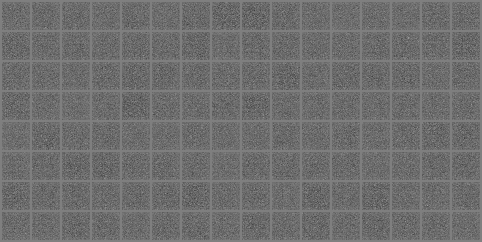

[1/5][100/468][216.1530 s]	Loss_D: -106.8035	Loss_G: 54.7267	Lip(D): 3.3777


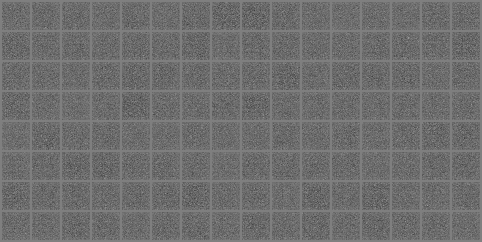

[1/5][200/468][431.6647 s]	Loss_D: -177.5699	Loss_G: 89.6162	Lip(D): 3.7461


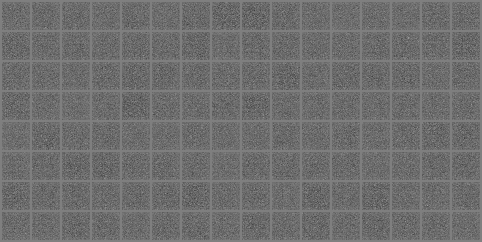

[1/5][300/468][643.2867 s]	Loss_D: -254.0158	Loss_G: 127.2493	Lip(D): 2.5819


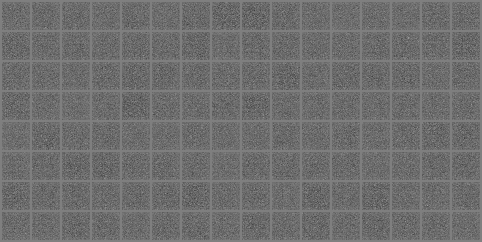

[1/5][400/468][852.7172 s]	Loss_D: -336.8877	Loss_G: 168.3380	Lip(D): 2.5713


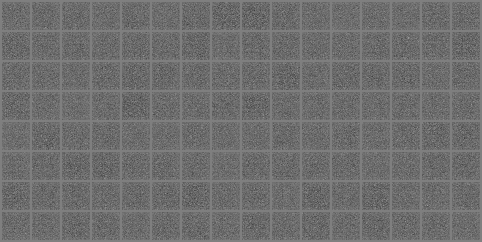

[2/5][0/468][999.7193 s]	Loss_D: -397.6387	Loss_G: 198.4063	Lip(D): 2.8083


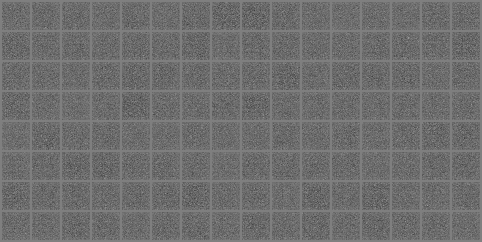

[2/5][100/468][1211.2503 s]	Loss_D: -491.5858	Loss_G: 245.2219	Lip(D): 2.7872


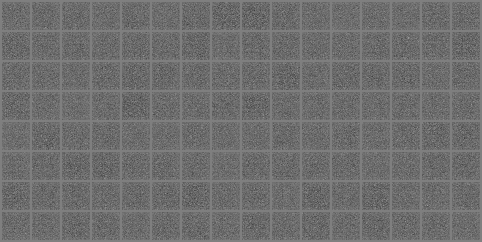

[2/5][200/468][1421.4885 s]	Loss_D: -594.5931	Loss_G: 296.2180	Lip(D): 3.0144


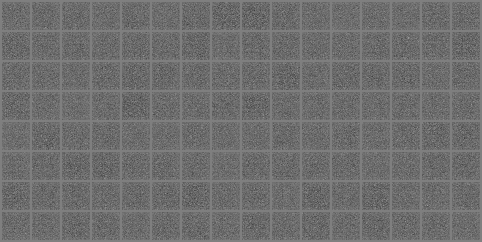

[2/5][300/468][1632.5324 s]	Loss_D: -702.4075	Loss_G: 349.8372	Lip(D): 3.3582


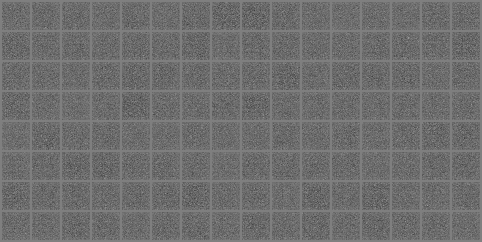

[2/5][400/468][1841.7772 s]	Loss_D: -819.7525	Loss_G: 407.9851	Lip(D): 3.7032


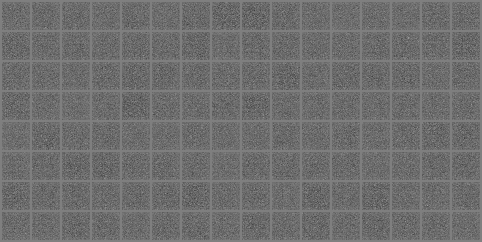

[3/5][0/468][1984.6028 s]	Loss_D: -902.7246	Loss_G: 449.2911	Lip(D): 3.6211


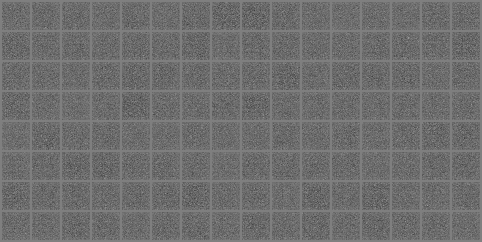

[3/5][100/468][2192.9797 s]	Loss_D: -1029.0233	Loss_G: 512.4733	Lip(D): 4.4408


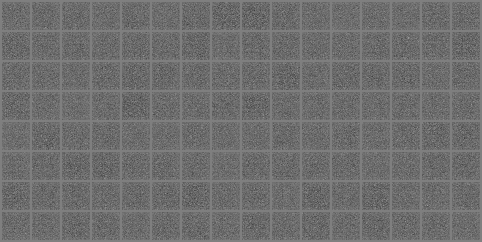

[3/5][200/468][2401.0735 s]	Loss_D: -1165.0923	Loss_G: 579.8232	Lip(D): 3.8790


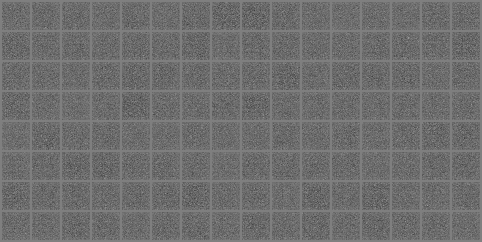

[3/5][300/468][2608.5195 s]	Loss_D: -1307.8878	Loss_G: 650.8373	Lip(D): 4.8486


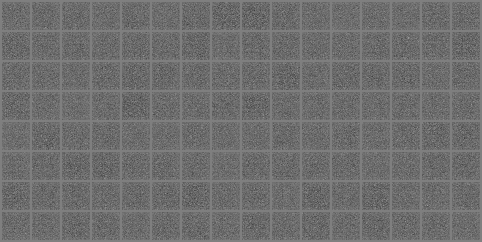

[3/5][400/468][2815.9129 s]	Loss_D: -1457.6044	Loss_G: 724.9257	Lip(D): 4.3159


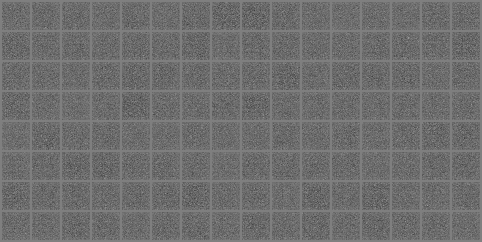

[4/5][0/468][2958.0810 s]	Loss_D: -1562.6410	Loss_G: 777.0500	Lip(D): 4.9393


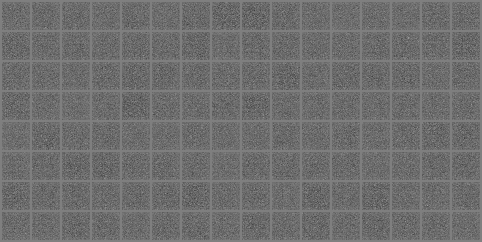

[4/5][100/468][3165.0821 s]	Loss_D: -1721.9294	Loss_G: 856.3220	Lip(D): 5.6059


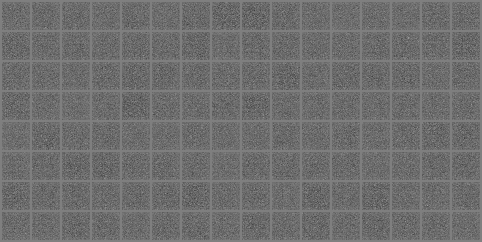

KeyboardInterrupt: 

In [11]:
torch.manual_seed(1)  # initialize random seed for reproducibility

num_epochs = 5
log_every = 100
gpw = 0.1         # weight of gradient penalty term

G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init);
D.apply(weights_init);

optimD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

zviz = torch.randn(batch_size,nz,1,1).to(device)

t0 = time.time()
for epoch in range(num_epochs):
    # For each batch in the train_loader
    for i, batch in enumerate(train_loader, 0):

        ############################
        # Batchs of real and fake images
        real = batch[0].to(device)
        fake = G(torch.randn(batch_size, nz, 1, 1, device=device))
        faked = fake.detach()

        ############################
        # Update D network
        ### ... ###
        D.zero_grad()
        Dloss = -torch.mean(D(real)) + torch.mean(D(faked)) + gpw*gradient_penalty(D,real,faked)
        Dloss.backward()
        optimD.step()

        ############################
        # Update G network
        ### ... ###
        G.zero_grad()
        Gloss = -torch.mean(D(faked))
        Gloss.backward()
        optimG.step()

        ############################
        # Display training stats and visualize
        if i % log_every == 0:
            print('[%d/%d][%d/%d][%.4f s]\tLoss_D: %.4f\tLoss_G: %.4f\tLip(D): %.4f'
                  % (epoch+1, num_epochs, i, len(train_loader), time.time()-t0, Dloss.item(), Gloss.item(),meanvariation(D,real,faked)))
            show(G,zviz)

print('Total learning time = ',time.time()-t0)

# Save final generator in a variable for later use
wgan = Generator()
wgan.load_state_dict(G.state_dict())


In [ ]:
# Save final generator for later use
torch.save(G.state_dict(), 'wgan.pt')
wgan = Generator()
wgan.load_state_dict(G.state_dict())


<br/><br/><br/><br/><br/>

# Part 2 BONUS: Let's play with the Generator

## Interpolation in latent space:

**QUESTION:**
Generate 2 sets of 10 latent variable $z_0$ and $z_1$ and display the generated images by the latent variables:
$$
z_\alpha = (1-\alpha) z_0 + \alpha z_1
$$
for $\alpha$ varying between $0$ and $1$.

Display all the images in a grid of height 10 and width 20 images.

In [ ]:
# You may load a trained generator from a file
# G = Generator().to(device)
# G.load_state_dict(torch.hub.load_state_dict_from_url('https://perso.telecom-paristech.fr/aleclaire/mva/tp/wgan_epoch100.pt', progress=False))
# G.eval();  # Turn generator in evaluation mode to fix BatchNorm layers

minib = 10
nk = 30

z0 = torch.randn(minib, nz, 1, 1, device=device)
z1 = torch.randn(minib, nz, 1, 1, device=device)

genimages = torch.zeros((minib*nk,1,28,28))
for k in np.arange(nk):
    ### ... ###

pil_img = imshow(make_grid(genimages.to('cpu'),nrow=nk))

## Nearest Neighbor in the Dataset

In [ ]:
# load all the database
train_loader_all = data.DataLoader(train_set, batch_size=60000, shuffle=False, num_workers=2, drop_last=True)
y,labels = next(iter(train_loader_all))

realzeros = y[labels==0]
realones = y[labels==1]
realtwos = y[labels==2]
realthrees = y[labels==3]
imshow(make_grid(realzeros[0:128,:,:,:].to('cpu'),nrow=16));
imshow(make_grid(realones[0:128,:,:,:].to('cpu'),nrow=16));
imshow(make_grid(realtwos[0:128,:,:,:].to('cpu'),nrow=16));
imshow(make_grid(realthrees[0:128,:,:,:].to('cpu'),nrow=16));

**QUESTION:** For several samples of the generative model, compute the nearest neighbors in the whole dataset.

Display the samples and their nearest neighbor side by side.

In [ ]:
### ... ###